# Count map from $m_5$

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
import pyccl as ccl

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
from spectra import Spectrum

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Reference spectrum

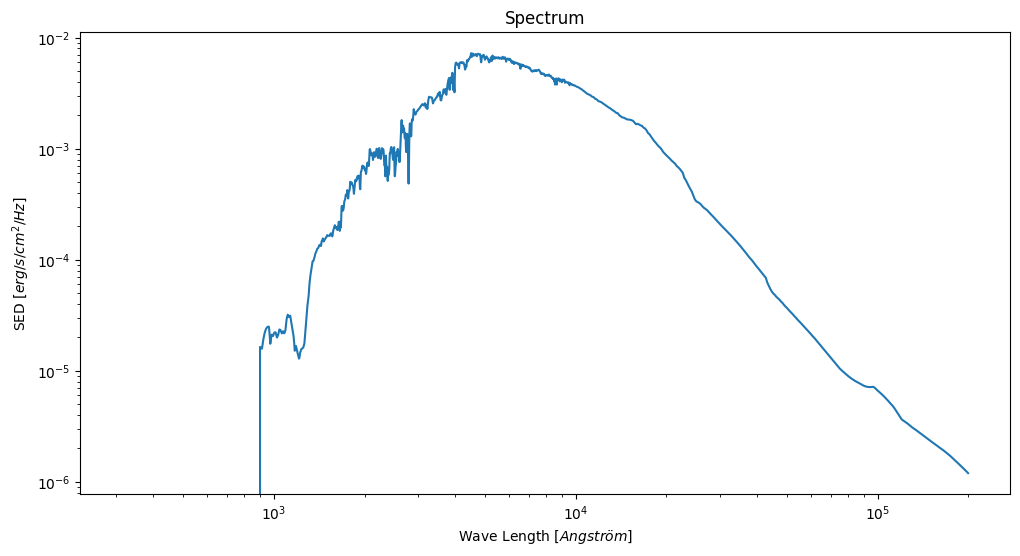

In [4]:
file = "../data/data SED/SED GAL/COSMOS/Ell1_A_0.sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True);

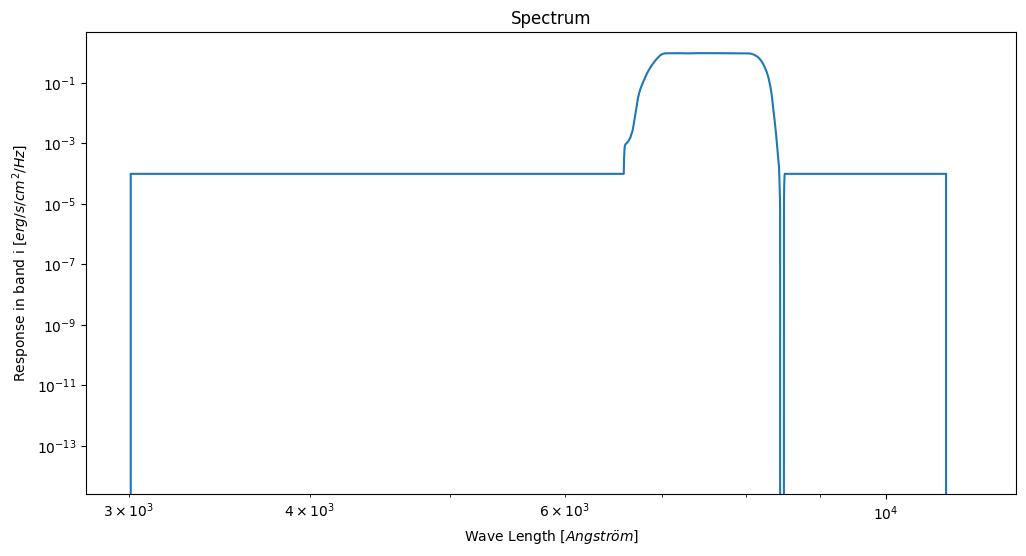

In [7]:
band = 'i'
file_band = f"../data/data LSST/filter_{band}.dat"
uFilter = Spectrum.read_sed(file_band, yname=f"Response in band {band}")
uFilter.wavelength = uFilter.wavelength*10
uFilter.plot(loglog=True);

In [8]:
_, response = refSpectum.get_surrounding(uFilter)
response = response.mean(axis=0)
ratio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {ratio}")

SED band i ratio : 0.09863703638357642


## $m_5$ magnitude

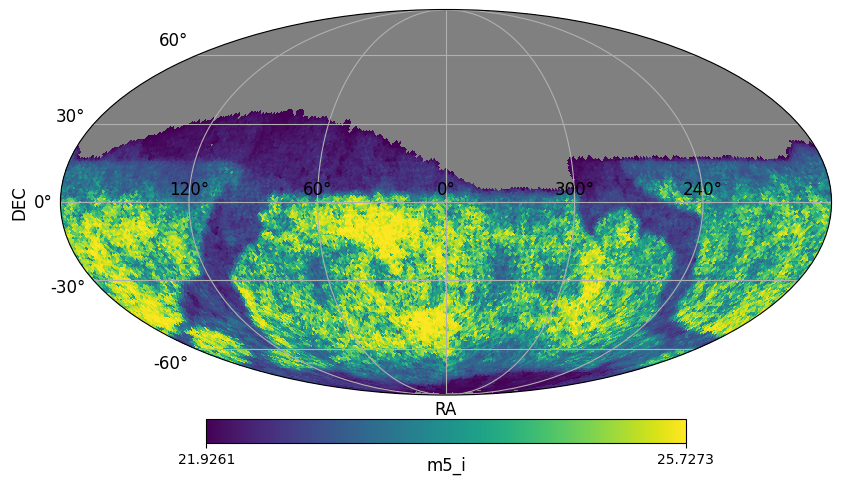

In [9]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
#band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 316.7 (χ²/ndof = 0.0)      │              Nfcn = 741              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │            time = 9.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  24.805   │   0.035   │   -0.035   │   0.035    │    0    │         │       │
│ 1 │ A    │  0.0222   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    259    │    25     │    -26     │     25     │    0    │   360   │       │
│ 3 │ dec  │    -79    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0027  │  0.0027   │    -26    │    26     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   0.00124    -59e-6    0.0844    0.0559 │
│   A │    -59e-6   7.3e-06 -5.470e-3 -3.961e-3 │
│  ra │    0.0844 -5.470e-3       625         5 │
│ dec │    0.0559 -3.961e-3         5      24.8 │
└─────┴─────────────────────────────────────────┘

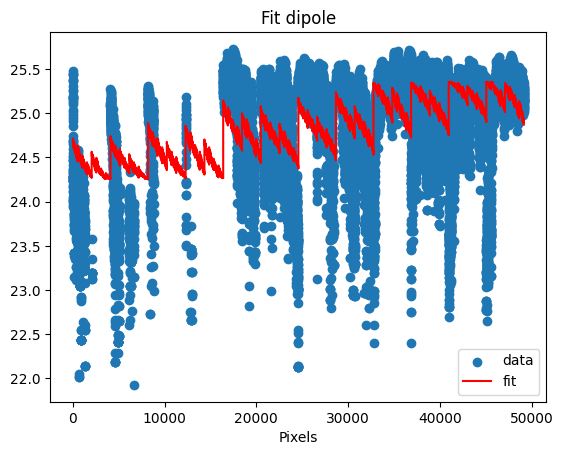

In [4]:
init =  (10, 1, 100, 40)
m = dm.fit_dipole("iMasked", init, plot_map=False)
m

## Ratio determination

In [10]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True, L_bandRatio=ratio)
dataN


Generating redshifts
Number of rejects = 690156
Accepted ratio = 76%

Generating dL
Generating luminosities
Number of rejects = 685231
Accepted ratio = 77%


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.42079753908109596,2386.3763486307453,50500920.854262464,-14.42824824323124,27.460446437188523
1.1011168383565617,7664.279415870821,418642597.76870024,-16.724608541580075,27.697748105368678
0.5614117260455778,3365.8696177890806,6679539.566286126,-12.231866316850164,30.403620127606374
0.44415376795593237,2543.894260272709,8199588.936890956,-12.454480202021864,29.573015075127174
0.5864832922175937,3547.9118568156437,9817038.030596154,-12.649951183569291,30.099912925535115
0.8247671944144824,5372.843627029093,220380392.21340737,-16.027932379120728,27.62308862541022
0.45871612007926965,2643.194462869633,4731832.407388413,-11.857573385834707,30.25307219343422
0.6024154706105032,3664.671203903412,793060896.3228741,-17.418266341312872,25.401908736743373


Saving LumDist in Simul_Figures/Simul_Schechter/Schechter_LumDist.pdf


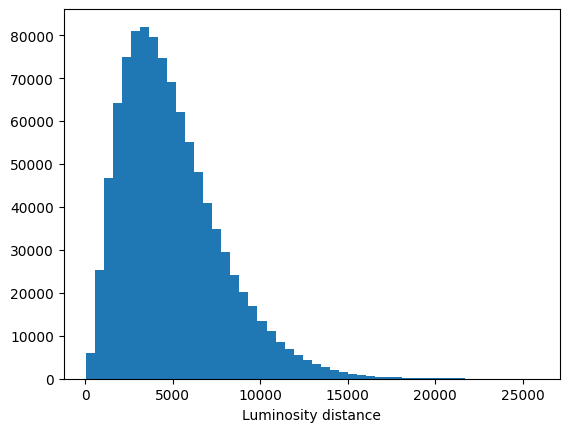

In [11]:
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=50);

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDist")

Saving LumDistLogLog in Simul_Figures/Simul_Schechter/Schechter_LumDistLogLog.pdf


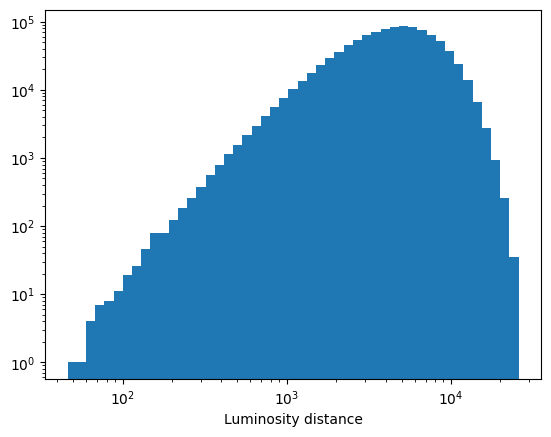

In [12]:
binsdL = np.logspace(np.log10(np.min(dataN["dL"])), np.log10(np.max(dataN["dL"])), 50)
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=binsdL, log=True);
plt.xscale('log')

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDistLogLog")

Saving ApparentMag in Simul_Figures/Simul_Schechter/Schechter_ApparentMag.pdf


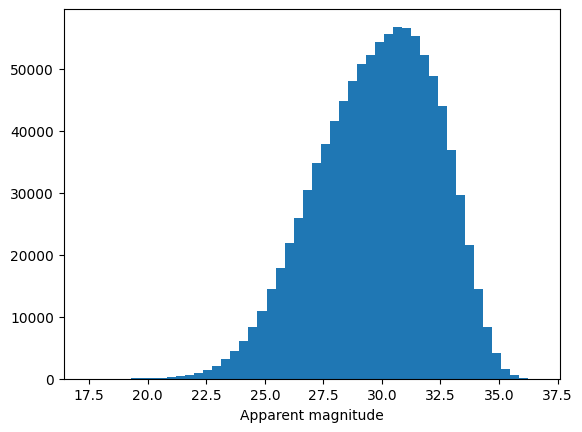

In [13]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$")

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag")

Saving ApparentMag_cut in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_cut.pdf


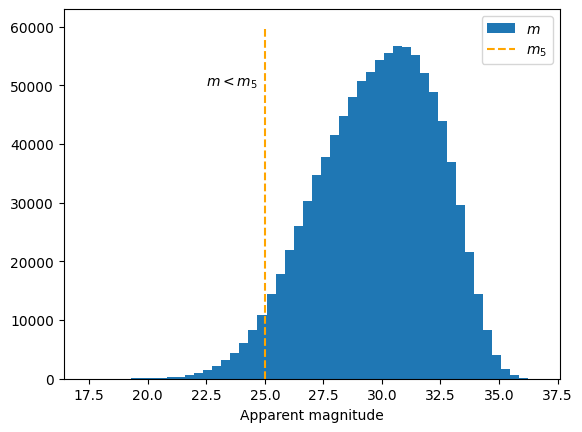

In [14]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$");
plt.vlines(25, 0, 60000, linestyles = 'dashed', colors="orange", label="$m_5$")
plt.text(22.5, 50000, "$m < m_5$")
plt.legend()

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag_cut")

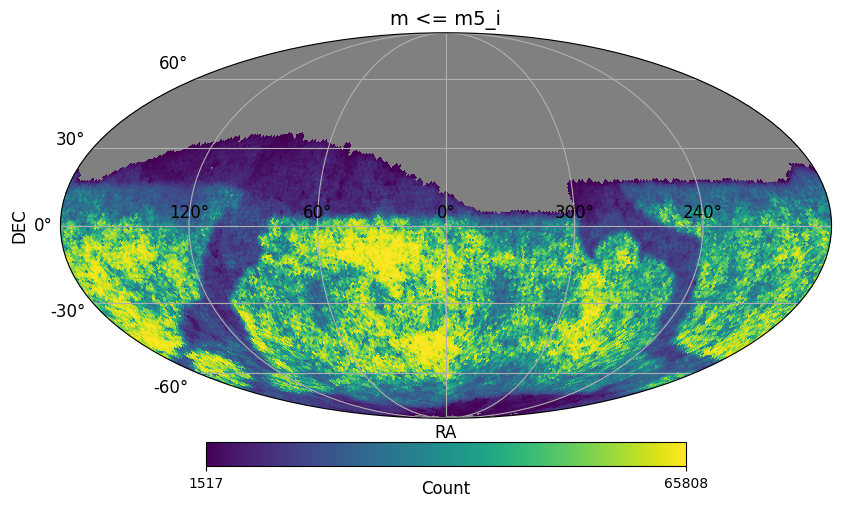

In [15]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= "m <= m5_i")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CountMap_m5band_i")

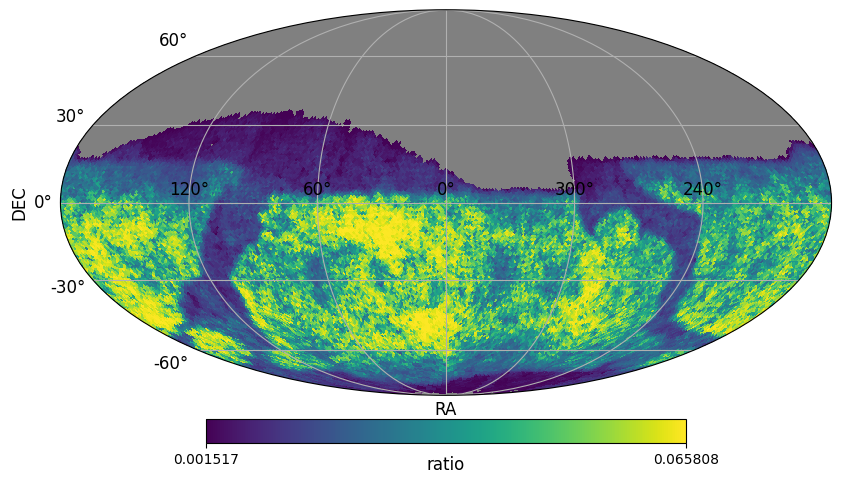

In [16]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "RatioMap_m5band_i")

## Souce sampling

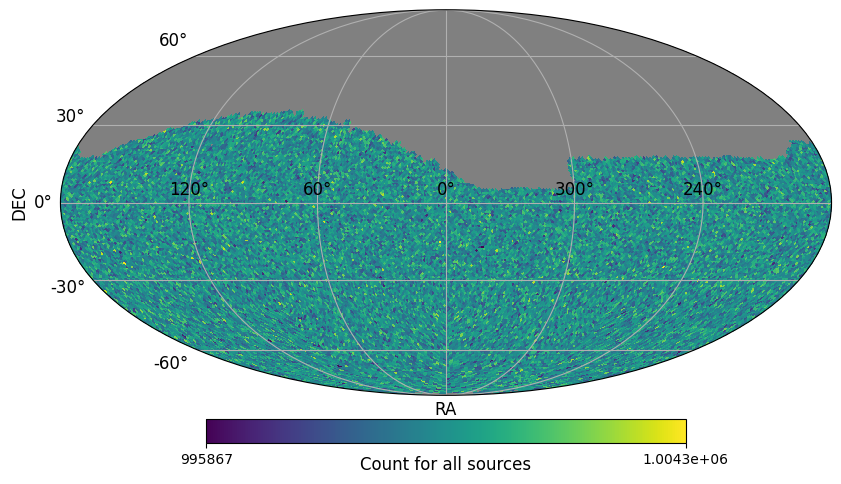

In [17]:
count_thMapper = CountMapper.from_map(np.random.poisson(NSource_px_th, npix))
count_thMapper._set_suffixTextPlot(unit = "all sources")
count_thMapper.set_mask(dm.m5iMasked.mask)
count_thMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "All_m_Map")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.337e+04 (χ²/ndof = 0.7)  │              Nfcn = 547              │
│ EDM = 0.000132 (Goal: 0.0002)    │            time = 7.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1.000011e6 │0.000007e6 │-0.000007e6 │ 0.000007e6 │    0    │         │       │
│ 1 │ A    │ 0.019e-3  │ 0.014e-3  │ -0.014e-3  │  0.014e-3  │    0    │    1    │       │
│ 2 │ ra   │  0.20e3   │  0.11e3   │  -0.20e3   │   0.16e3   │    0    │   360   │       │
│ 3 │ dec  │    77     │    27     │    -42     │     13     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.014e-3 │ 0.014e-3  │  -0.20e3  │  0.16e3   │    -42    │    13     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         50.4  59.91455e-6          150           40 │
│   A │  59.91455e-6     1.85e-10 255.79509e-6  72.21853e-6 │
│  ra │          150 255.79509e-6     1.48e+04        0.4e3 │
│ dec │           40  72.21853e-6        0.4e3          801 │
└─────┴─────────────────────────────────────────────────────┘

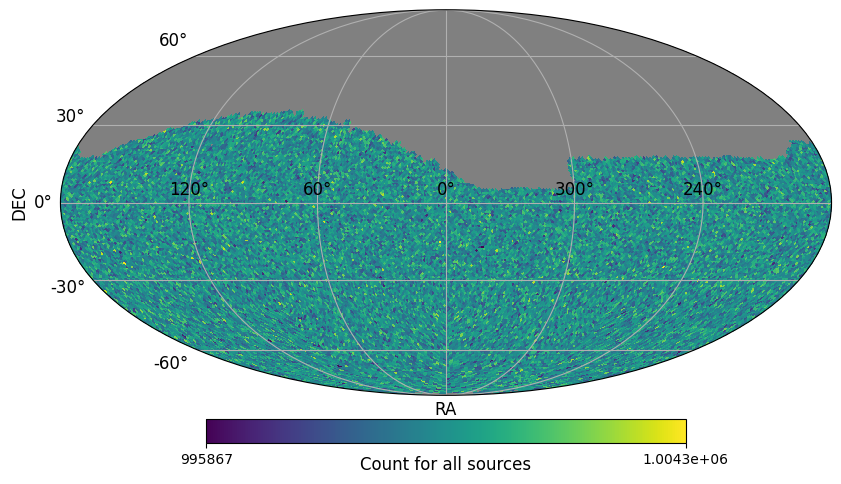

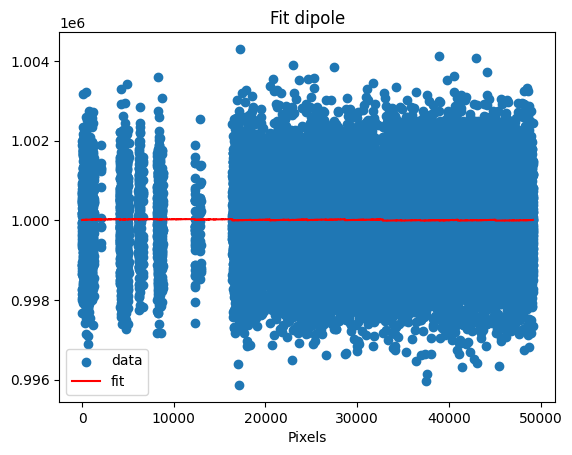

In [18]:
init =  (1e6, 0, 100, 40)
count_thMapper.fit_dipole("Masked", init)

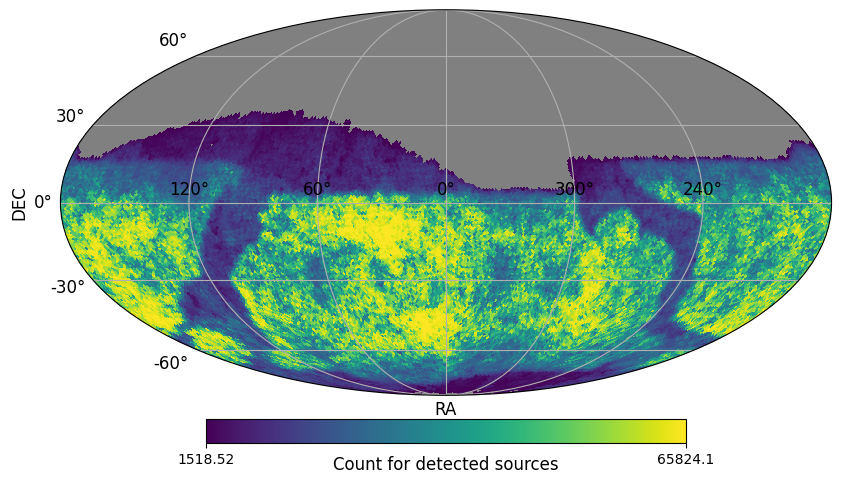

In [19]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "DetectMap_m5band_i")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.218e+08 (χ²/ndof = 4512.1)│              Nfcn = 418              │
│ EDM = 3.84e-05 (Goal: 0.0002)    │            time = 5.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 27.7634e3 │ 0.0011e3  │ -0.0011e3  │  0.0011e3  │    0    │         │       │
│ 1 │ A    │ 532.24e-3 │  0.08e-3  │  -0.08e-3  │  0.08e-3   │    0    │    1    │       │
│ 2 │ ra   │  254.485  │   0.030   │   -0.030   │   0.030    │    0    │   360   │       │
│ 3 │ dec  │  -77.230  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -1.1    │    1.1    │ -0.08e-3  │  0.08e-3  │   -0.03   │   0.03    │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │       1.18 -52.929e-6     3.1e-3    2.74e-3 │
│   A │ -52.929e-6   6.56e-09    -224e-9    -221e-9 │
│  ra │     3.1e-3    -224e-9   0.000891         -0 │
│ dec │    2.74e-3    -221e-9         -0   4.49e-05 │
└─────┴─────────────────────────────────────────────┘

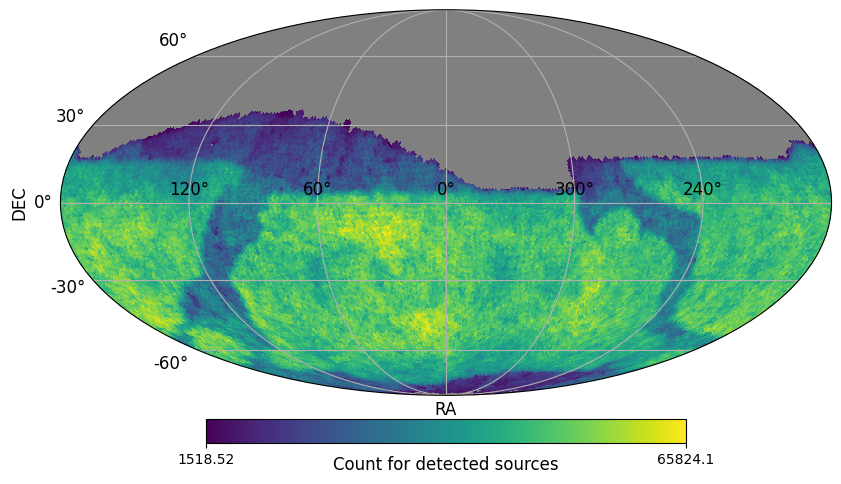

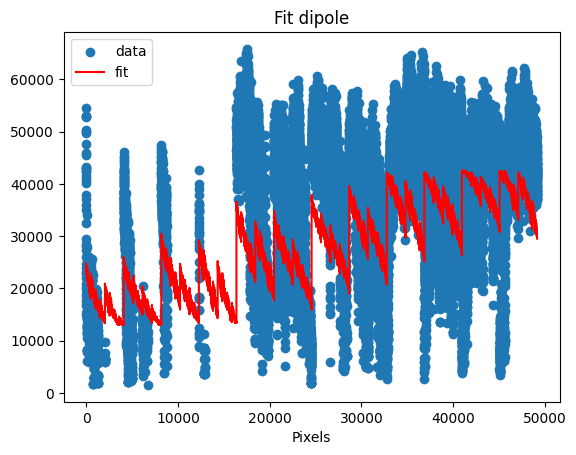

In [20]:
init =  (1e5, 1, 100, 40)
countDetectedMapper.fit_dipole("Masked", init)

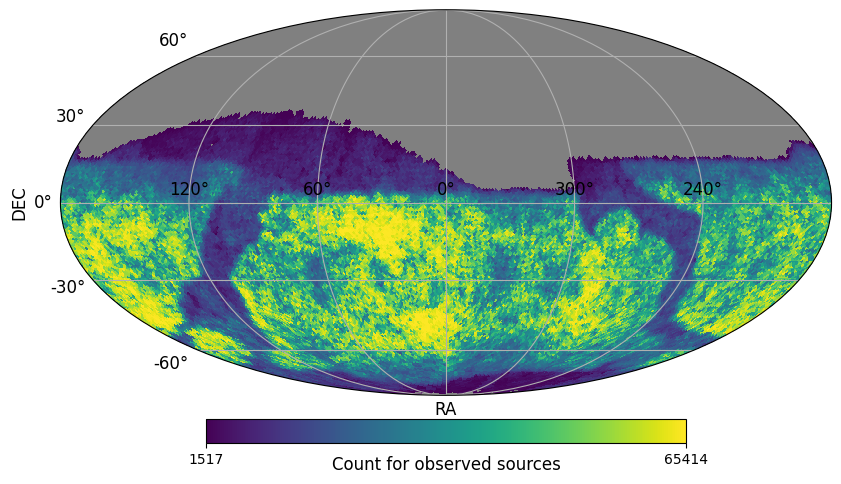

In [21]:
countObservedMapper = CountMapper.from_map(np.random.poisson(countDetectedMapper.map))
countObservedMapper._set_suffixTextPlot(unit = "observed sources")
countObservedMapper.set_mask(dm.m5iMasked.mask)
countObservedMapper.plot("Masked", norm='hist')

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "ObservMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.218e+08 (χ²/ndof = 4513.2)│              Nfcn = 464              │
│ EDM = 4.63e-05 (Goal: 0.0002)    │            time = 6.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 27.7598e3 │ 0.0011e3  │ -0.0011e3  │  0.0011e3  │    0    │         │       │
│ 1 │ A    │ 532.63e-3 │  0.08e-3  │  -0.08e-3  │  0.08e-3   │    0    │    1    │       │
│ 2 │ ra   │  254.451  │   0.030   │   -0.030   │   0.030    │    0    │   360   │       │
│ 3 │ dec  │  -77.239  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -1.1    │    1.1    │ -0.08e-3  │  0.08e-3  │   -0.03   │   0.03    │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │       1.18 -52.937e-6     3.2e-3    2.73e-3 │
│   A │ -52.937e-6   6.56e-09    -224e-9    -221e-9 │
│  ra │     3.2e-3    -224e-9   0.000891         -0 │
│ dec │    2.73e-3    -221e-9         -0   4.48e-05 │
└─────┴─────────────────────────────────────────────┘

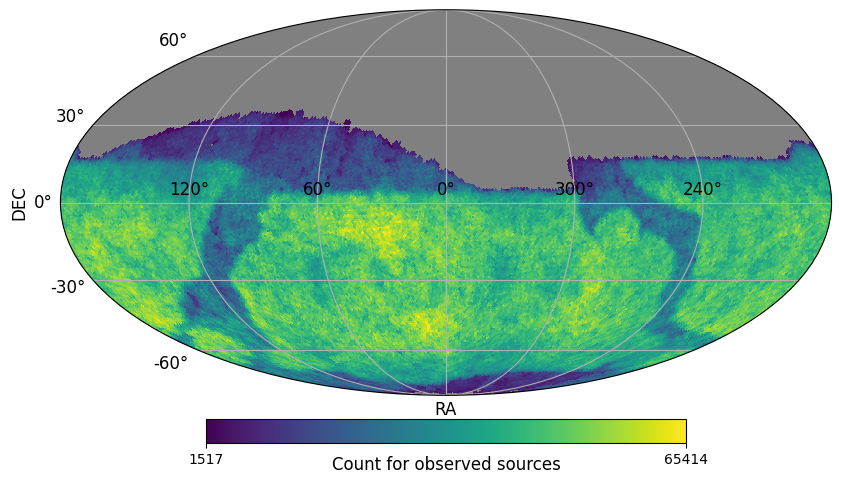

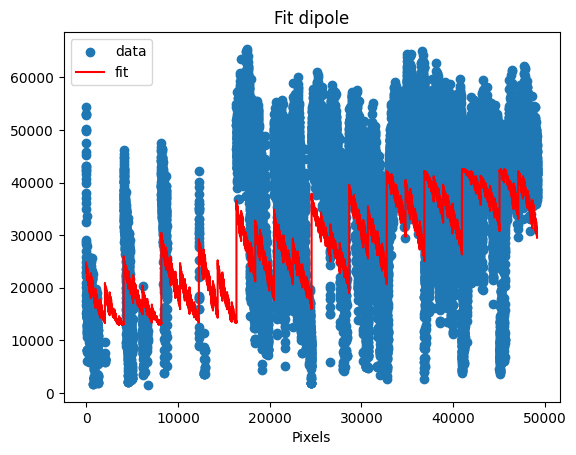

In [22]:
init =  (1e5, 1, 100, 40)
countObservedMapper.fit_dipole("Masked", init)

/tmp/ipykernel_5618/216236427.py:1: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


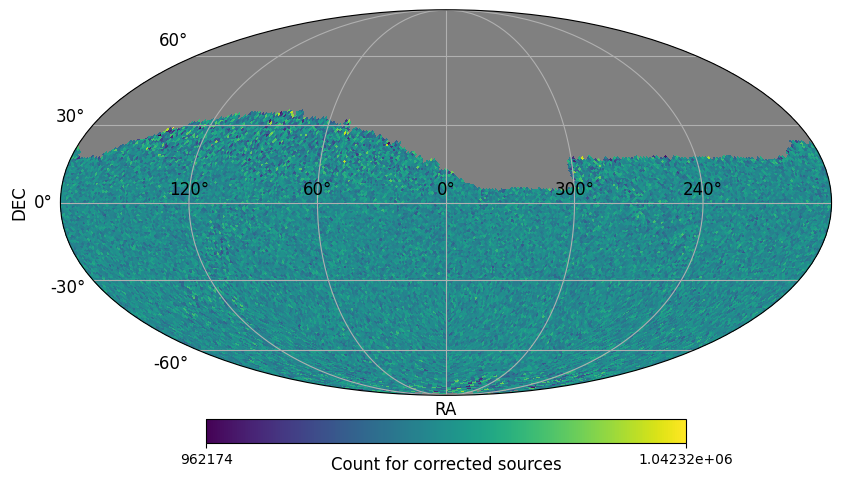

In [23]:
countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
countCorrectedMapper.fillna()
countCorrectedMapper._set_suffixTextPlot(unit = "corrected sources")
countCorrectedMapper.set_mask()
countCorrectedMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CorrectMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.136e+06 (χ²/ndof = 23.1) │              Nfcn = 434              │
│ EDM = 8.47e-05 (Goal: 0.0002)    │            time = 6.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.967e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │ 0.113e-3  │ 0.013e-3  │ -0.013e-3  │  0.013e-3  │    0    │    1    │       │
│ 2 │ ra   │    207    │    11     │    -11     │     11     │    0    │   360   │       │
│ 3 │ dec  │    -64    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.013e-3 │ 0.013e-3  │    -11    │    11     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         50.5 -55.07561e-6           10           14 │
│   A │ -55.07561e-6     1.68e-10 -23.05996e-6 -22.76299e-6 │
│  ra │           10 -23.05996e-6          113            4 │
│ dec │           14 -22.76299e-6            4         27.2 │
└─────┴─────────────────────────────────────────────────────┘

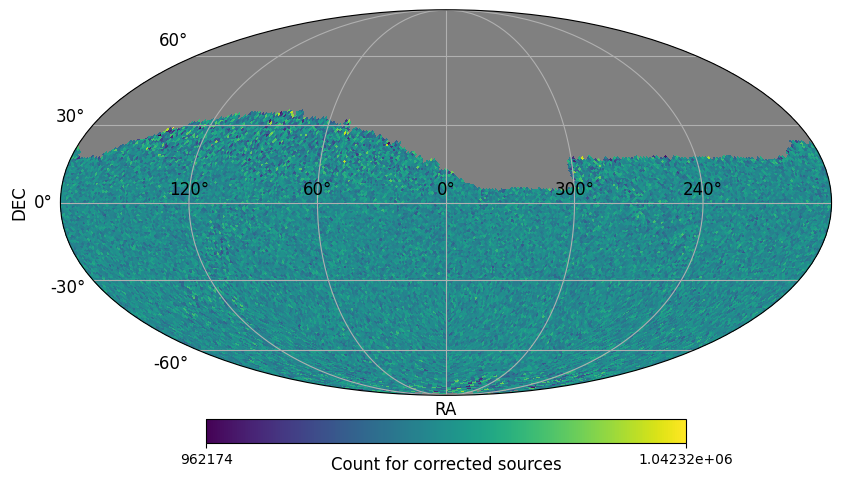

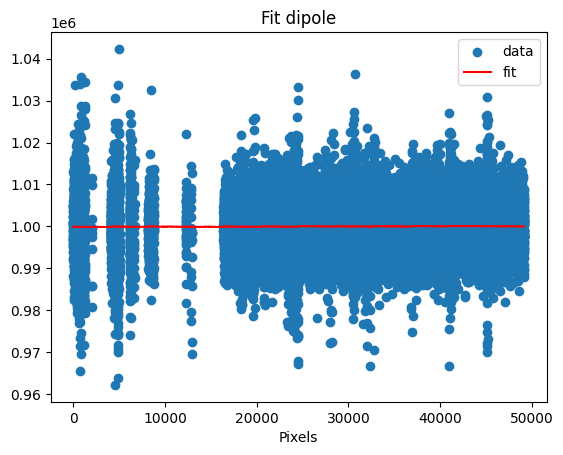

In [24]:
init =  (1e6, 0, 100, 40)
countCorrectedMapper.fit_dipole("Masked", init)

## Smoothing the map

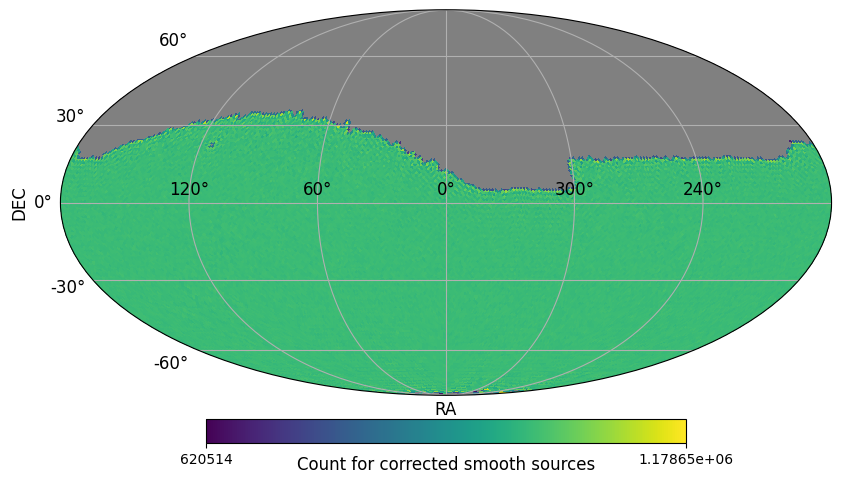

In [25]:
countSmoothMapper = CountMapper.from_map(hp.smoothing(countCorrectedMapper.map, nest=True, sigma=0.005))
countSmoothMapper._set_suffixTextPlot(unit = "corrected smooth sources")
countSmoothMapper.set_mask(countCorrectedMapper.mapMasked.mask)
countSmoothMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "SmoothMap_m5band_i_poissOnly")